<a href="https://colab.research.google.com/github/uilkaalmeida/senac_pos_ia/blob/main/NuvemPalavras2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 95.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Processando: https://www.who.int/publications/i/item/9789241565639
Processando: https://cisa.org.br/artigo/110-adolescencia-e-consumo-de-alcool/
Processando: https://www.sbpt.org.br/portal/alcool-e-adolescentes/
Processando: https://cisa.org.br/pesquisa/artigos-cientificos/artigo/item/75-alcool-e-jovens
Processando: https://ocid.es.gov.br/consumo-de-alcool-adolescentes
Processando: https://www.scielo.br/j/pee/a/Q9vFZrYKyXL9kq7FkHP7fhy/


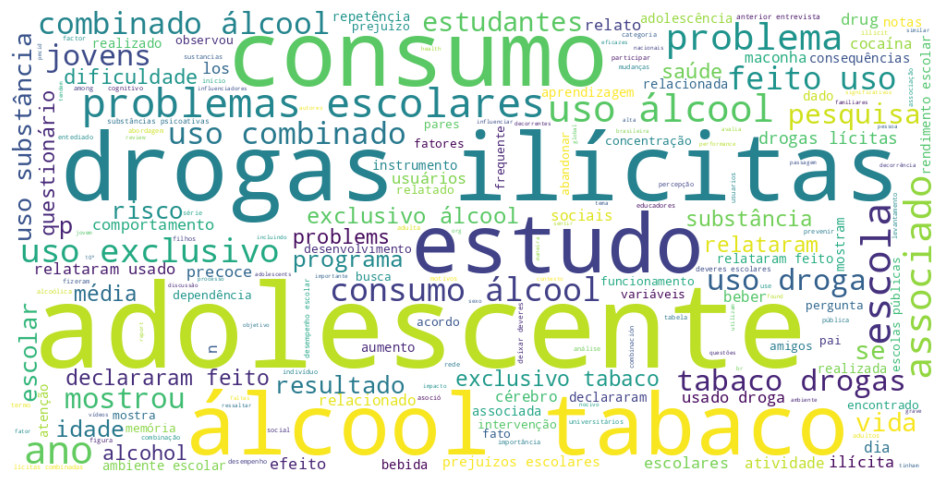

In [2]:
# Instalar bibliotecas (se ainda não instaladas)
!pip install spacy requests beautifulsoup4 wordcloud
!python -m spacy download pt_core_news_sm

# Importar bibliotecas
import spacy
import requests
from bs4 import BeautifulSoup
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Carregar o modelo de português
nlp = spacy.load("pt_core_news_sm")

# Lista de URLs
urls = [
    "https://www.who.int/publications/i/item/9789241565639",
    "https://cisa.org.br/artigo/110-adolescencia-e-consumo-de-alcool/",
    "https://www.sbpt.org.br/portal/alcool-e-adolescentes/",
    "https://cisa.org.br/pesquisa/artigos-cientificos/artigo/item/75-alcool-e-jovens",
    "https://ocid.es.gov.br/consumo-de-alcool-adolescentes",
    "https://www.scielo.br/j/pee/a/Q9vFZrYKyXL9kq7FkHP7fhy/"
]

# Função para extrair o texto visível de uma URL
def extrair_texto(url):
    try:
        response = requests.get(url, timeout=10)
        soup = BeautifulSoup(response.content, 'html.parser')
        paragrafos = soup.find_all('p')
        texto = ' '.join([p.get_text() for p in paragrafos])
        return texto
    except Exception as e:
        print(f"Erro ao acessar {url}: {e}")
        return ""

# Função para filtrar palavras por classe gramatical
def filtrar_palavras(texto):
    doc = nlp(texto)
    palavras_filtradas = [
        token.text.lower() for token in doc
        if token.pos_ in ['NOUN', 'ADJ', 'VERB'] and len(token.text) > 2 and not token.is_stop
    ]
    return ' '.join(palavras_filtradas)

# Extrair e filtrar o texto de todos os links
texto_total = ""
for url in urls:
    print(f"Processando: {url}")
    texto_bruto = extrair_texto(url)
    texto_filtrado = filtrar_palavras(texto_bruto)
    texto_total += " " + texto_filtrado

# Gerar a nuvem de palavras
def gerar_nuvem(texto):
    wc = WordCloud(width=1000, height=500, background_color='white').generate(texto)
    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title("", fontsize=14)
    plt.show()

gerar_nuvem(texto_total)
